# Long-Short Strategy, Preparing Alpha Factors and Features

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import talib
from talib import RSI, BBANDS, MACD, ATR

In [3]:
MONTH = 21
YEAR = 12 * MONTH

In [4]:
START = '2010-01-01'
END = '2017-12-31'

In [5]:
sns.set_style('darkgrid')
idx = pd.IndexSlice

In [6]:
percentiles = [.001, .01, .02, .03, .04, .05]
percentiles += [1-p for p in percentiles[::-1]]

In [7]:
T = [1, 5, 10, 21, 42, 63]

## Loading Quandl Wiki Stock Prices & Meta Data

In [8]:
DATA_STORE = '/home/sabateri/code/courses/machine-learning-for-trading/data/assets.h5'
ohlcv = ['adj_open', 'adj_close', 'adj_low', 'adj_high', 'adj_volume']
with pd.HDFStore(DATA_STORE) as store:
    prices = (store['quandl/wiki/prices']
              .loc[idx[START:END, :], ohlcv] # select OHLCV columns from 2010 until 2017
              .rename(columns=lambda x: x.replace('adj_', '')) # simplify column names
              .swaplevel()
              .sort_index())
    metadata = (store['us_equities/stocks'].loc[:, ['marketcap', 'sector']])


In [9]:
prices.volume /= 1e3 # make vol figures a bit smaller
prices.index.names = ['symbol', 'date']
metadata.index.name = 'symbol'

## Remove stocks with insufficient observations

We require at least 7 years of data; we simplify and select using both in- and out-of-sample period; please be aware that it would be more accurate to use only the training period to remove data to avoid lookahead bias.

In [ ]:
min_obs = 7 * YEAR
nobs = prices.groupby(level='symbol').size()
keep = nobs[nobs > min_obs].index
prices = prices.loc[idx[keep, :], :]

### Align price and meta data

In [11]:
metadata = metadata[~metadata.index.duplicated() & metadata.sector.notnull()]
metadata.sector = metadata.sector.str.lower().str.replace(' ', '_')

In [12]:
shared = (prices.index.get_level_values('symbol').unique()
          .intersection(metadata.index))
metadata = metadata.loc[shared, :]
prices = prices.loc[idx[shared, :], :]

### Limit universe to 1,000 stocks with highest market cap

Again, we simplify and use the entire sample period, not just the training period, to select our universe.

In [13]:
universe = metadata.marketcap.nlargest(1000).index
prices = prices.loc[idx[universe, :], :]
metadata = metadata.loc[universe]

In [14]:
metadata.sector.value_counts()

sector
consumer_services        187
finance                  160
technology               131
health_care               97
capital_goods             96
public_utilities          65
consumer_non-durables     63
basic_industries          59
energy                    58
consumer_durables         34
miscellaneous             27
transportation            23
Name: count, dtype: int64

In [15]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1977529 entries, ('AAPL', Timestamp('2010-01-04 00:00:00')) to ('OI', Timestamp('2017-04-25 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    1977529 non-null  float64
 1   close   1977529 non-null  float64
 2   low     1977529 non-null  float64
 3   high    1977529 non-null  float64
 4   volume  1977529 non-null  float64
dtypes: float64(5)
memory usage: 83.7+ MB


In [16]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, AAPL to OI
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   marketcap  1000 non-null   float64
 1   sector     1000 non-null   object 
dtypes: float64(1), object(1)
memory usage: 23.4+ KB


### Rank assets by Rolling Average Dollar Volume

#### Compute dollar volume

In [17]:
prices['dollar_vol'] = prices[['close', 'volume']].prod(1).div(1e3)

#### 21-day moving average

In [18]:
# compute dollar volume to determine universe
dollar_vol_ma = (prices
                 .dollar_vol
                 .unstack('symbol')
                 .rolling(window=21, min_periods=1) # 1 trading month
                 .mean())

#### Rank stocks by moving average

In [19]:
prices['dollar_vol_rank'] = (dollar_vol_ma
                            .rank(axis=1, ascending=False)
                            .stack('symbol')
                            .swaplevel())

In [20]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1977529 entries, ('AAPL', Timestamp('2010-01-04 00:00:00')) to ('OI', Timestamp('2017-04-25 00:00:00'))
Data columns (total 7 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   open             1977529 non-null  float64
 1   close            1977529 non-null  float64
 2   low              1977529 non-null  float64
 3   high             1977529 non-null  float64
 4   volume           1977529 non-null  float64
 5   dollar_vol       1977529 non-null  float64
 6   dollar_vol_rank  1977529 non-null  float64
dtypes: float64(7)
memory usage: 113.9+ MB


## Add some Basic Factors

See [appendix](../24_alpha_factor_library) for details on the below indicators.

### Compute the Relative Strength Index

In [21]:
def apply_rsi(group, timeperiod=14):
    return pd.Series(RSI(group.values, timeperiod=timeperiod), index=group.index)

In [22]:
#prices['rsi'] = prices.groupby(level='symbol').close.apply(RSI)
prices['rsi'] = (prices.groupby(level='symbol',group_keys=False).close.
                apply(apply_rsi))

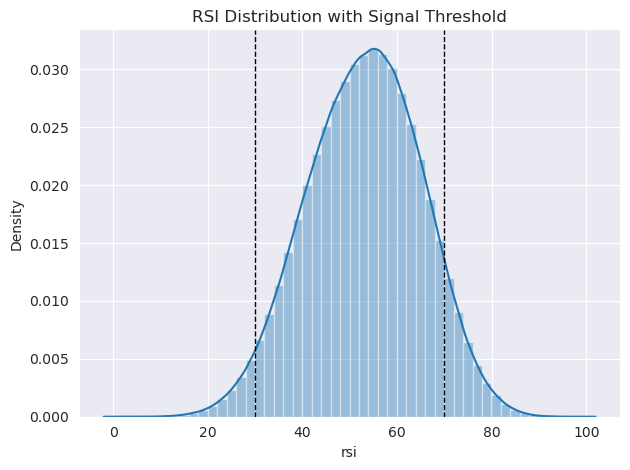

In [ ]:
ax = sns.distplot(prices.rsi.dropna())
ax.axvline(30, ls='--', lw=1, c='k')
ax.axvline(70, ls='--', lw=1, c='k')
ax.set_title('RSI Distribution with Signal Threshold')
sns.despine()
plt.tight_layout()

### Compute Bollinger Bands

In [24]:
def compute_bb(close):
    high, mid, low = BBANDS(close, timeperiod=20)
    return pd.DataFrame({'bb_high': high, 'bb_low': low}, index=close.index)

In [25]:
prices = (prices.join(prices
                      .groupby(level='symbol',group_keys=False)
                      .close
                      .apply(compute_bb)))

In [26]:
prices['bb_high'] = prices.bb_high.sub(prices.close).div(prices.bb_high).apply(np.log1p)
prices['bb_low'] = prices.close.sub(prices.bb_low).div(prices.close).apply(np.log1p)

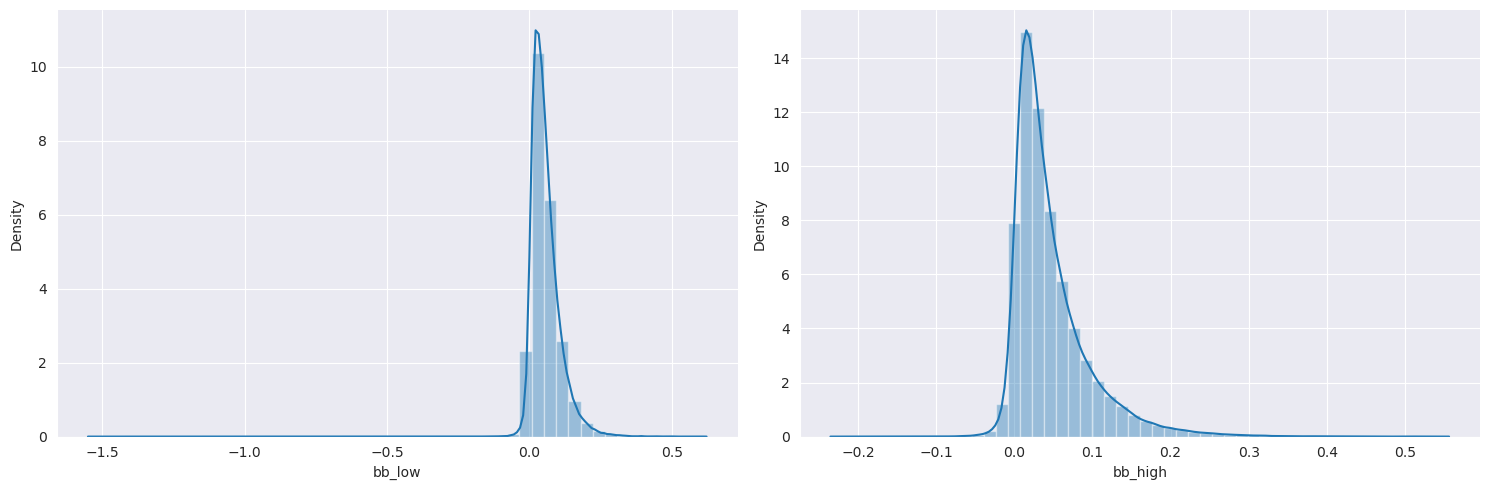

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
sns.distplot(prices.loc[prices.dollar_vol_rank<100, 'bb_low'].dropna(), ax=axes[0])
sns.distplot(prices.loc[prices.dollar_vol_rank<100, 'bb_high'].dropna(), ax=axes[1])
sns.despine()
plt.tight_layout()

### Compute Average True Range

In [28]:
prices['NATR'] = prices.groupby(level='symbol', 
                                group_keys=False).apply(lambda x: 
                                                        talib.NATR(x.high, x.low, x.close))

In [29]:
def compute_atr(stock_data):
    df = ATR(stock_data.high, stock_data.low, 
             stock_data.close, timeperiod=14)
    return df.sub(df.mean()).div(df.std())

In [30]:
prices['ATR'] = (prices.groupby('symbol', group_keys=False)
                 .apply(compute_atr))

### Compute Moving Average Convergence/Divergence

In [31]:
prices['PPO'] = prices.groupby(level='symbol',group_keys=False).close.apply(talib.PPO)

In [32]:
def compute_macd(close):
    macd = MACD(close)[0]
    return (macd - np.mean(macd))/np.std(macd)

In [33]:
prices['MACD'] = (prices
                  .groupby('symbol', group_keys=False)
                  .close
                  .apply(compute_macd))

### Combine Price and Meta Data

In [34]:
metadata.sector = pd.factorize(metadata.sector)[0].astype(int)
prices = prices.join(metadata[['sector']])

## Compute Returns

### Historical Returns

In [35]:
by_sym = prices.groupby(level='symbol').close
for t in T:
    prices[f'r{t:02}'] = by_sym.pct_change(t)

### Daily historical return deciles

In [36]:
for t in T:
    prices[f'r{t:02}dec'] = (prices[f'r{t:02}']
                             .groupby(level='date',group_keys=False)
                             .apply(lambda x: pd.qcut(x, 
                                                      q=10, 
                                                      labels=False, 
                                                      duplicates='drop')))

### Daily sector return deciles

In [37]:
for t in T:
    prices[f'r{t:02}q_sector'] = (prices
                                  .groupby(['date', 'sector'])[f'r{t:02}']
                                  .transform(lambda x: pd.qcut(x, 
                                                               q=5, 
                                                               labels=False, 
                                                               duplicates='drop')))

### Compute Forward Returns

In [38]:
for t in [1, 5, 21]:
    prices[f'r{t:02}_fwd'] = prices.groupby(level='symbol')[f'r{t:02}'].shift(-t)

## Remove outliers

In [39]:
prices[[f'r{t:02}' for t in T]].describe()

,r01,r05,r10,r21,r42,r63
count,1.976529e+06,1.972529e+06,1.967529e+06,1.956529e+06,1.935529e+06,1.914529e+06
mean,7.596449e-04,3.767097e-03,7.436317e-03,1.572296e-02,3.139236e-02,4.655684e-02
std,2.236538e-02,4.955731e-02,6.822961e-02,9.830703e-02,1.357883e-01,1.649622e-01
min,-8.757416e-01,-8.768476e-01,-8.778415e-01,-8.802285e-01,-8.867366e-01,-8.863481e-01
25%,-8.076219e-03,-1.717452e-02,-2.286837e-02,-3.036969e-02,-3.506785e-02,-3.666427e-02
50%,6.607034e-04,3.719447e-03,7.201961e-03,1.508856e-02,2.915396e-02,4.249371e-02
75%,9.503610e-03,2.440981e-02,3.707844e-02,5.932203e-02,9.317334e-02,1.220448e-01
max,1.216425e+01,1.252657e+01,1.252657e+01,1.252657e+01,1.181643e+01,1.166968e+01


We remove daily returns above 100 percent as these are more likely to represent data errors; we are using the 100 percent cutoff here in a somewhat ad-hoc fashion; you would want to apply more careful exploratory and historical analysis to decide which assets are truly not representative of the sample period.

In [40]:
outliers = prices[prices.r01 > 1].index.get_level_values('symbol').unique()

In [41]:
prices = prices.drop(outliers, level='symbol')

## Create time and sector dummy variables

In [42]:
prices['year'] = prices.index.get_level_values('date').year
prices['month'] = prices.index.get_level_values('date').month
prices['weekday'] = prices.index.get_level_values('date').weekday

## Store Model Data

In [43]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1964714 entries, ('AAPL', Timestamp('2010-01-04 00:00:00')) to ('OI', Timestamp('2017-04-25 00:00:00'))
Data columns (total 39 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   open             1964714 non-null  float64
 1   close            1964714 non-null  float64
 2   low              1964714 non-null  float64
 3   high             1964714 non-null  float64
 4   volume           1964714 non-null  float64
 5   dollar_vol       1964714 non-null  float64
 6   dollar_vol_rank  1964714 non-null  float64
 7   rsi              1950812 non-null  float64
 8   bb_high          1945847 non-null  float64
 9   bb_low           1945841 non-null  float64
 10  NATR             1950812 non-null  float64
 11  ATR              1950812 non-null  float64
 12  PPO              1939889 non-null  float64
 13  MACD             1931945 non-null  float64
 14  sector           1964714 non-null  int64

In [44]:
prices.drop(['open', 'close', 'low', 'high', 'volume'], axis=1).to_hdf('data.h5', 'model_data')